In [1]:

import sys
from pathlib import Path

# Add parent directory to sys.path for modular imports
parent_dir = Path(r"A:\Github\Agentic-Ai-LangGraph-Agent")
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

In [2]:
parent_dir

WindowsPath('A:/Github/Agentic-Ai-LangGraph-Agent')

In [ ]:
from nodes.search_news import SearchNewsNode
from langgraph.graph import StateGraph ,START  , END
from langgraph.checkpoint.memory import MemorySaver
from core.state import BlueskyAgentState
from nodes.generate_hook import GenerateHookNode
from nodes.generate_content import GenerateContentNode
from nodes.error_handler import ErrorHandlerNode
from nodes.generate_image import GenerateImageNode
# from nodes.human_review_news import HumanReviewNewsNode
from nodes.human_review_news import HumanReviewNewsNode
from nodes.human_approval import HumanApprovalNode
from nodes.publish_to_bluesky import PublishToBlueskyNode
from edges.routing import route_after_search ,route_after_generation 

a:\Github\Agentic-Ai-LangGraph-Agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
search_news = SearchNewsNode()
generate_hook = GenerateHookNode()
generate_content = GenerateContentNode()
error_handler = ErrorHandlerNode()
human_review_news = HumanReviewNewsNode()
generate_image = GenerateImageNode()
human_approval = HumanApprovalNode()
publish_to_bluesky = PublishToBlueskyNode()

Loaded as API: https://cf0ebeccf83d2fc514.gradio.live/


In [4]:
graph = StateGraph(BlueskyAgentState)

In [5]:
checkpointer = MemorySaver()

In [6]:
graph.add_node("search_news" , search_news )
graph.add_node("human_review_news" , human_review_news )
graph.add_node("generate_hook" , generate_hook )
graph.add_node("generate_content" , generate_content )
graph.add_node("error_handler" , error_handler )
graph.add_node("generate_image" , generate_image )
graph.add_node("human_approval" , human_approval )
graph.add_node("publish_to_bluesky" , publish_to_bluesky )

graph.add_edge(START , "search_news")
graph.add_conditional_edges("search_news" , route_after_search , {"human_review_news": "human_review_news", "error_handler": "error_handler"})
graph.add_edge("error_handler" , END)
graph.add_edge("generate_hook" , "generate_content")
graph.add_edge("generate_content" , 'generate_image')
graph.add_conditional_edges("generate_image" , route_after_generation , {"human_approval": "human_approval", "error_handler": "error_handler"})
graph.add_edge("publish_to_bluesky" , END)
graph.add_edge("error_handler" , END)



workflow = graph.compile(checkpointer= checkpointer)

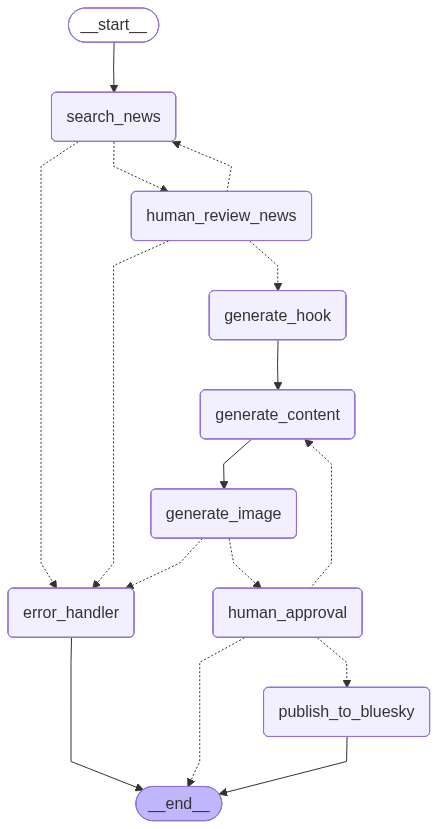

In [7]:
workflow

In [8]:
config = {"configurable": {"thread_id": "approval-123"}}

In [9]:
result = workflow.invoke({"topic" : "AI Agents 2026" } , config=config)

In [21]:
result

{'topic': 'AI Agents 2026',
 'raw_news': [{'title': "AI agents arrived in 2025 – here's what happened and the ...",
   'url': 'https://theconversation.com/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026-272325',
   'snippet': '## New power, new risks\n\nAs agents became more capable, their risks became harder to ignore. In November, Anthropic disclosed how its Claude Code agent had been misused to automate parts of a cyberattack. The incident illustrated a broader concern: By automating repetitive, technical work, AI agents can also lower the barrier for malicious activity.\n\nThis tension defined much of 2025. AI agents expanded what individuals and organizations could do, but they also amplified existing vulnerabilities',
   'source': 'theconversation.com',
   'published_at': 'recent'},
  {'title': 'AI Agent Trends 2026: From Chatbots to Autonomous Business ...',
   'url': 'https://www.gappsgroup.com/blog/ai-agent-trends-2026-from-chatbots-to-autonomous

In [22]:
print(result["__interrupt__"])

[Interrupt(value={'question': 'Review the fetched news articles. Pick which ones to use.', 'articles': [{'index': 0, 'title': "AI agents arrived in 2025 – here's what happened and the ...", 'source': 'theconversation.com', 'url': 'https://theconversation.com/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026-272325'}, {'index': 1, 'title': 'AI Agent Trends 2026: From Chatbots to Autonomous Business ...', 'source': 'www.gappsgroup.com', 'url': 'https://www.gappsgroup.com/blog/ai-agent-trends-2026-from-chatbots-to-autonomous-business-ecosystems'}, {'index': 2, 'title': 'What to Expect From AI in 2026: Personal Agents, Mega Alliances ...', 'source': 'www.goldmansachs.com', 'url': 'https://www.goldmansachs.com/insights/articles/what-to-expect-from-ai-in-2026-personal-agents-mega-alliances'}, {'index': 3, 'title': 'AI agent trends 2026 report | Google Cloud', 'source': 'cloud.google.com', 'url': 'https://cloud.google.com/resources/content/ai-agent-trends-2026'}, 

In [14]:
interrupt_payload = result.get("__interrupt__")
if not interrupt_payload:
    print("ERROR: graph did not pause at human_review_news")
    print("workflow_status:", result.get("workflow_status"))
    print("error_message:  ", result.get("error_message"))
    exit(1)
 

In [15]:
interrupt_payload[0]

Interrupt(value={'question': 'Review the fetched news articles. Pick which ones to use.', 'articles': [{'index': 0, 'title': "AI agents arrived in 2025 – here's what happened and ...", 'source': 'theconversation.com', 'url': 'https://theconversation.com/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026-272325'}, {'index': 1, 'title': "AI agents arrived in 2025 – here's what happened and the ...", 'source': 'www.mountainadvocate.com', 'url': 'https://www.mountainadvocate.com/premium/theconversation/stories/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026,52510'}, {'index': 2, 'title': 'The future of AI agents: Key trends to watch in 2026 - Salesmate CRM', 'source': 'www.salesmate.io', 'url': 'https://www.salesmate.io/blog/future-of-ai-agents/'}, {'index': 3, 'title': 'What to Expect From AI in 2026: Personal Agents, Mega ...', 'source': 'www.goldmansachs.com', 'url': 'https://www.goldmansachs.com/insights/articles/what-to-expect

In [16]:
interrupt_payload[0].value

{'question': 'Review the fetched news articles. Pick which ones to use.',
 'articles': [{'index': 0,
   'title': "AI agents arrived in 2025 – here's what happened and ...",
   'source': 'theconversation.com',
   'url': 'https://theconversation.com/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026-272325'},
  {'index': 1,
   'title': "AI agents arrived in 2025 – here's what happened and the ...",
   'source': 'www.mountainadvocate.com',
   'url': 'https://www.mountainadvocate.com/premium/theconversation/stories/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026,52510'},
  {'index': 2,
   'title': 'The future of AI agents: Key trends to watch in 2026 - Salesmate CRM',
   'source': 'www.salesmate.io',
   'url': 'https://www.salesmate.io/blog/future-of-ai-agents/'},
  {'index': 3,
   'title': 'What to Expect From AI in 2026: Personal Agents, Mega ...',
   'source': 'www.goldmansachs.com',
   'url': 'https://www.goldmansachs.com/insig

In [17]:

# Show what interrupt() surfaced
print("\n--- interrupt payload ---")
payload = interrupt_payload[0].value
print(f"question    : {payload['question']}")
print(f"retry_count : {payload['retry_count']}")
print(f"articles    : {len(payload['articles'])} fetched")

 



--- interrupt payload ---
question    : Review the fetched news articles. Pick which ones to use.
retry_count : 0
articles    : 5 fetched


In [18]:
for a in payload["articles"]:
    print(f"  [{a['index']}] {a['title']}  ({a['source']})")

  [0] AI agents arrived in 2025 – here's what happened and ...  (theconversation.com)
  [1] AI agents arrived in 2025 – here's what happened and the ...  (www.mountainadvocate.com)
  [2] The future of AI agents: Key trends to watch in 2026 - Salesmate CRM  (www.salesmate.io)
  [3] What to Expect From AI in 2026: Personal Agents, Mega ...  (www.goldmansachs.com)
  [4] AI Agent Trends 2026: From Chatbots to Autonomous Business ...  (www.gappsgroup.com)


In [10]:
from langgraph.types import Command

In [ ]:
# Phase 2 — human picks articles and resumes
print("\n" + "=" * 60)
print("  Phase 2: approving articles 0 and 1...")
print("=" * 60)
result = workflow.invoke(
    Command(resume={"action": "approve", "approved_indices": [0, 1 ]}),
    config=config,
)
 



  Phase 2: approving articles 0 and 1...


In [25]:
result

{'topic': 'AI Agents 2026',
 'raw_news': [{'title': "AI agents arrived in 2025 – here's what happened and the ...",
   'url': 'https://theconversation.com/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026-272325',
   'snippet': '## New power, new risks\n\nAs agents became more capable, their risks became harder to ignore. In November, Anthropic disclosed how its Claude Code agent had been misused to automate parts of a cyberattack. The incident illustrated a broader concern: By automating repetitive, technical work, AI agents can also lower the barrier for malicious activity.\n\nThis tension defined much of 2025. AI agents expanded what individuals and organizations could do, but they also amplified existing vulnerabilities',
   'source': 'theconversation.com',
   'published_at': 'recent'},
  {'title': 'AI Agent Trends 2026: From Chatbots to Autonomous Business ...',
   'url': 'https://www.gappsgroup.com/blog/ai-agent-trends-2026-from-chatbots-to-autonomous

In [26]:
print(result["__interrupt__"])

[Interrupt(value={'question': 'Review the Bluesky post and image. Approve, edit, or reject.', 'post': {'caption': 'In November 2025 Anthropic revealed its Claude Code agent was used to automate parts of a cyber‑attack, highlighting how AI agents can lower the barrier for malicious activity.\nThe Anthropic disclosure in November 2025 showed that Claude Code could be repurposed to script reconnaissance, credential‑stuffing and lateral‑movement steps, turning routine code into a weapon. That episode crystallized a new reality: when agents automate repetitive, technical work they also lower the entry barrier for threat actors, turning what was once a specialist skill into a commodity.\nIn 2026 the conversation has moved from isolated chatbots to autonomous business ecosystems. As the Gapps Group report notes, AI agents now blend advanced reasoning with the ability to act across APIs, databases and workflow tools, enabling organizations to orchestrate end‑to‑end processes without human micr

In [44]:
# Phase 2 — human picks articles and resumes
print("\n" + "=" * 60)
print("  Phase 2: approving articles 0 and 1...")
print("=" * 60)
result = workflow.invoke(
    Command(resume={'action': 'edit', 'instructions': 'Make The image more clear'}),
    config=config,
)


  Phase 2: approving articles 0 and 1...


In [45]:
result

{'topic': 'AI Agents 2026',
 'raw_news': [{'title': 'The future of AI agents: Key trends to watch in 2026 - Salesmate CRM',
   'url': 'https://www.salesmate.io/blog/future-of-ai-agents/',
   'snippet': 'Salesmate\nSalesmate\n\nWhy Salesmate?\n\nSalesmate Updates\nSalesmate\nSalesmate\n\nWhy Salesmate?\n\nSalesmate Updates\n\n# The future of AI agents: Key trends to watch in 2026\n\nShivani Tripathi\nThe future of AI agents: Key trends to watch in 2026\n\n##### Table of content\n\n###### Key takeaways\n\nAI agents are no longer an experimental side project inside enterprises; they’re quickly becoming part of the core operating fabric.\n\nBy 2026, IDC expects AI copilots to be embedded in nearly 80% of enterprise workpl',
   'source': 'www.salesmate.io',
   'published_at': 'recent'},
  {'title': 'AI agent trends 2026 report | Google Cloud',
   'url': 'https://cloud.google.com/resources/content/ai-agent-trends-2026',
   'snippet': "# Discover the five trends driving business transformatio

In [46]:
# Phase 2 — human picks articles and resumes
print("\n" + "=" * 60)
print("  Phase 2: approving articles 0 and 1...")
print("=" * 60)
result = workflow.invoke(
    Command(resume={'action': 'reject'}),
    config=config,
)


  Phase 2: approving articles 0 and 1...


In [47]:
result

{'topic': 'AI Agents 2026',
 'raw_news': [{'title': 'The future of AI agents: Key trends to watch in 2026 - Salesmate CRM',
   'url': 'https://www.salesmate.io/blog/future-of-ai-agents/',
   'snippet': 'Salesmate\nSalesmate\n\nWhy Salesmate?\n\nSalesmate Updates\nSalesmate\nSalesmate\n\nWhy Salesmate?\n\nSalesmate Updates\n\n# The future of AI agents: Key trends to watch in 2026\n\nShivani Tripathi\nThe future of AI agents: Key trends to watch in 2026\n\n##### Table of content\n\n###### Key takeaways\n\nAI agents are no longer an experimental side project inside enterprises; they’re quickly becoming part of the core operating fabric.\n\nBy 2026, IDC expects AI copilots to be embedded in nearly 80% of enterprise workpl',
   'source': 'www.salesmate.io',
   'published_at': 'recent'},
  {'title': 'AI agent trends 2026 report | Google Cloud',
   'url': 'https://cloud.google.com/resources/content/ai-agent-trends-2026',
   'snippet': "# Discover the five trends driving business transformatio

In [27]:
interrupt_payload = result.get("__interrupt__")
if not interrupt_payload:
    print("ERROR: graph did not pause at human_review_news")
    print("workflow_status:", result.get("workflow_status"))
    print("error_message:  ", result.get("error_message"))
    exit(1)

In [30]:
# Phase 3 — show final state after both gen nodes finish
print("\n" + "=" * 60)
print("  RESULTS")
print("=" * 60)
 
viral_hook   = result.get("hook")
post_content = result.get("post_caption") or []
image_prompt  = result.get("image_prompt") or []
hashtags     = result.get("hashtags") or []
final_post = result.get("final_post")
file_path = result.get("image_path")
 
print(f"\nviral_hook ({len(viral_hook or '')} chars):")
print(f"  {viral_hook}")
 
print(f"\npost_content ({len(post_content)} body tweets):")

 
print(f"\nhashtags : {hashtags}")
 
print(f"\nfinal_draft ({len(image_prompt)} assembled tweets):")

 
print(f"\nworkflow_status: {result.get('workflow_status')}")


  RESULTS

viral_hook (178 chars):
  By 2026, 3,466 global executives say the era of simple prompts is over—AI agents now orchestrate end‑to‑end workflows semi‑autonomously, reshaping speed‑to‑value for enterprises.

post_content (954 body tweets):

hashtags : ['#AIAgents', '#EnterpriseAI', '#DigitalTransformation', '#SpeedToValue', '#FutureOfWork']

final_draft (412 assembled tweets):

workflow_status: image_generated


In [29]:
image_prompt

'wide shot of a sleek open‑plan office where a senior executive stands before a large transparent display showing interconnected workflow diagrams and AI avatars coordinating tasks across finance, supply chain, and HR screens, team members monitoring real‑time analytics on laptops, ambient soft white lighting from ceiling panels, shallow depth of field, Canon EOS R5 24‑70mm f/2.8, photorealistic, cinematic, 8k'

In [31]:
file_path

'A:\\Github\\Agentic-Ai-LangGraph-Agent\\data\\7796c22176ca4d33bd5796052e7a54df.png'